In [1]:
import anndata as ad
import os
import pandas as pd
import matplotlib.pyplot as plt

## Download results

In [2]:
def dict_to_pd(d):
    rows = []

    for outer_key, inner in d.items():
        row = {
            "dataset_id": inner["dataset_id"],
            "method_id": inner["method_id"],
        }
        
        # Use values from "d" as column names
        for col_name, value in zip(inner["metric_ids"], inner["metric_values"]):
            row[col_name] = value
            
        rows.append(row)
    
    df = pd.DataFrame(rows, index=d.keys())
    return df

In [3]:
methods_path = '../../data_lpm_style_all_25_epochs/benchmark/results/metrics/methods/'

In [4]:
os.listdir(methods_path + 'nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_1/stability')

['seed_12',
 'seed_2',
 'seed_14',
 'seed_10',
 'seed_3',
 'seed_11',
 'seed_13',
 'seed_0',
 'seed_1',
 'seed_4']

In [5]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [6]:
os.listdir(methods_path)

['nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_1',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_20',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_5',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_10',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_none',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_25',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_25',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_20',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_fp_fixed_1',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_10',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_10',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_5',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_1',
 'nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_20',


In [7]:
methods_err = {}
methods_corr = {}
for item in os.listdir(methods_path):
    if 'mol_emb_subsample' in item:
        if 'nn_retraining_with_pseudolabels_mol_emb_subsample_fp' in item:
            name = item.replace('_1', '')
        else:
            name = item
        stability_path = methods_path + item + '/stability'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[name + '_' + seed] = err
            methods_corr[name + '_' + seed] = corr

In [8]:
df_method_err = dict_to_pd(methods_err)

In [9]:
df_method_corr = dict_to_pd(methods_corr)

In [10]:
df_method_err['method_name'] = df_method_err.index.str.split('_seed_').str[0]
df_method_err['seed'] = df_method_err.index.str.split('_seed_').str[1].astype(int)

In [11]:
df_method_corr['method_name'] = df_method_corr.index.str.split('_seed_').str[0]
df_method_corr['seed'] = df_method_corr.index.str.split('_seed_').str[1].astype(int)

## Mean rowwise error

### Methods

In [12]:
df_method_err.sort_values(by="mean_rowwise_rmse")

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_20_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.853659,0.599427,nn_retraining_with_pseudolabels_mol_emb_subsam...,14
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_20_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.854034,0.599548,nn_retraining_with_pseudolabels_mol_emb_subsam...,13
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_20_seed_11,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.854408,0.599994,nn_retraining_with_pseudolabels_mol_emb_subsam...,11
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_20_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.854656,0.599484,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_20_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.854687,0.600170,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
...,...,...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_5_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,1.011420,0.743872,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_5_seed_14,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,1.011500,0.744767,nn_retraining_with_pseudolabels_mol_emb_subsam...,14
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_5_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,1.014733,0.747287,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_5_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,1.018651,0.750065,nn_retraining_with_pseudolabels_mol_emb_subsam...,2


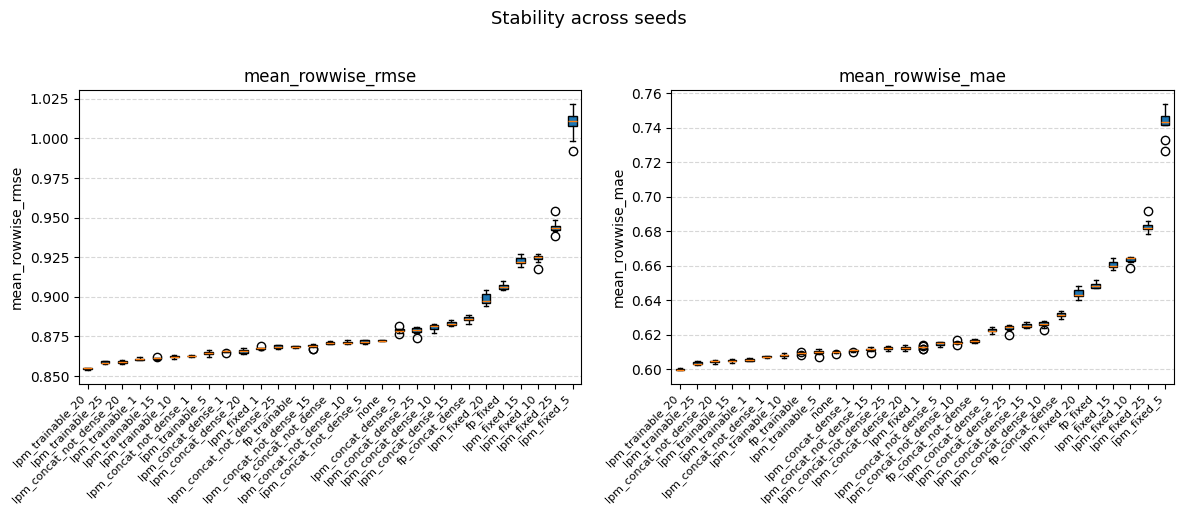

<Figure size 640x480 with 0 Axes>

In [13]:
metrics = ["mean_rowwise_rmse", "mean_rowwise_mae"]
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
for ax, metric in zip(axes, metrics):
    # collect values per method, ordered by median
    methods_ordered = (
        df_method_err.groupby("method_name")[metric]
        .median()
        .sort_values()
        .index.tolist()
    )
    data_per_method = [
        df_method_err.loc[df_method_err["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        # strip the long common prefix for readability
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.suptitle("Stability across seeds", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.savefig('all_25_epochs_1.png', dpi=1000)

## Mean rowwise correlation

### Methods

In [31]:
df_method_corr.sort_values(by="mean_rowwise_pearson", ascending=False)
#df_method_corr.sort_values(by="mean_rowwise_spearman", ascending=False)

,dataset_id,method_id,mean_rowwise_pearson,mean_rowwise_spearman,mean_rowwise_cosine,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_25_seed_10,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.285843,0.275502,0.289422,nn_retraining_with_pseudolabels_mol_emb_subsam...,10
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_25_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.285626,0.275633,0.289155,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_25_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.285187,0.274842,0.288661,nn_retraining_with_pseudolabels_mol_emb_subsam...,13
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_25_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.285132,0.275247,0.288641,nn_retraining_with_pseudolabels_mol_emb_subsam...,12
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_not_dense_25_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.284711,0.274869,0.288229,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
...,...,...,...,...,...,...,...
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_15_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.209164,0.202397,0.213114,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_15_seed_12,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.208933,0.201581,0.212751,nn_retraining_with_pseudolabels_mol_emb_subsam...,12
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_15_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.208536,0.201754,0.212466,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_fixed_15_seed_13,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_fixed,0.206503,0.199995,0.210375,nn_retraining_with_pseudolabels_mol_emb_subsam...,13


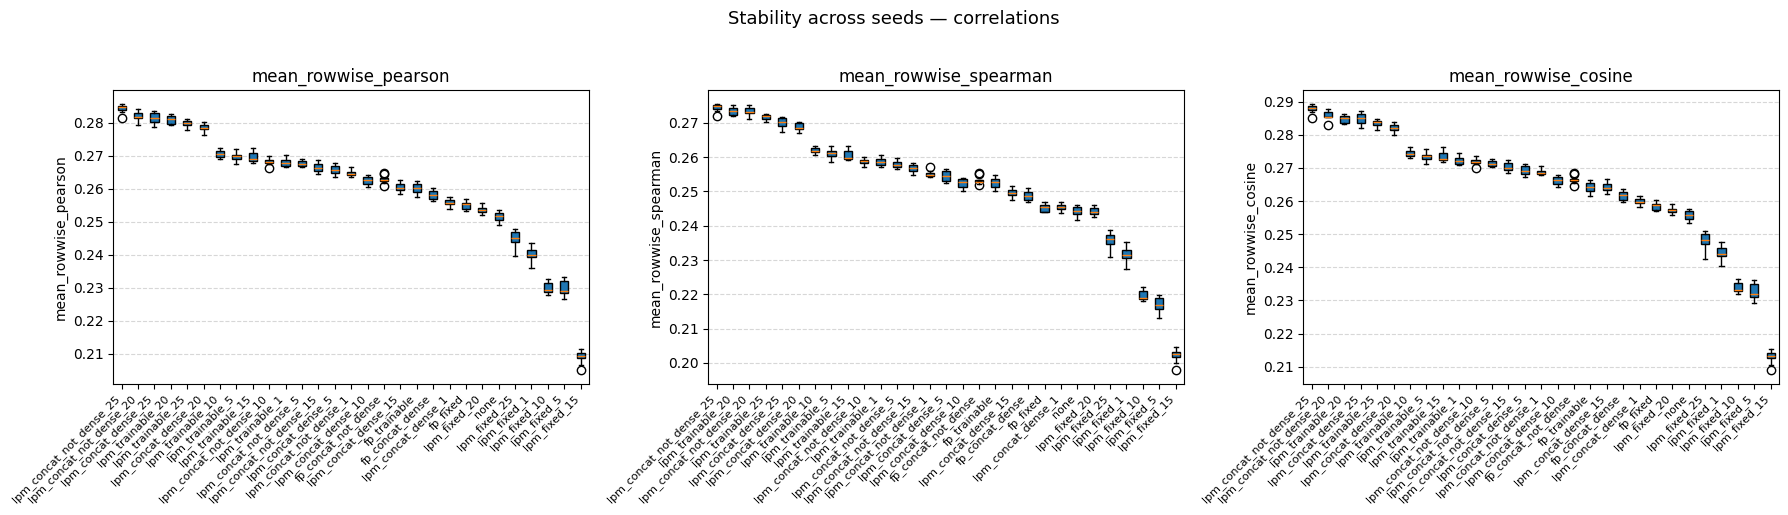

In [38]:
corr_metrics = ["mean_rowwise_pearson", "mean_rowwise_spearman", "mean_rowwise_cosine"]
fig, axes = plt.subplots(1, len(corr_metrics), figsize=(6 * len(corr_metrics), 5))
for ax, metric in zip(axes, corr_metrics):
    # higher correlation is better → sort descending
    methods_ordered = (
        df_method_corr.groupby("method_name")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_per_method = [
        df_method_corr.loc[df_method_corr["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.suptitle("Stability across seeds — correlations", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('all_25_epochs_2.png', dpi=1000)
plt.show()

In [36]:
! pwd

/ictstr01/home/icb/olga.novitskaia/op3_signatures/notebooks/models_reproducibility
